# Notebook 2 — Invariant and Equivariant Representations

**Module 1, Section 1.2 — Geometric Learning**

This notebook accompanies Section 1.2. We will:

1. Empirically verify the **commutative diagram of equivariance** for a 2-D convolution.
2. Show how forcing invariance destroys directional information.
3. Implement a **permutation-equivariant** layer (DeepSets style) and check that it commutes with $S_n$ — while a fully-connected layer does not.
4. ⭐ **Striking example**: train a *segmentation* head with two architectures (FC vs convolutional). The convolutional one is translation-equivariant — translating the input image translates the predicted mask. The FC one is not, and produces nonsense under translation.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from scipy.ndimage import shift

np.random.seed(0)
plt.rcParams['figure.dpi'] = 110

## 1. Translation equivariance of convolution

We test the identity
$$f(\text{translate}(x, \delta)) = \text{translate}(f(x), \delta).$$

Translate first, then convolve — vs — convolve first, then translate. The two should agree pixel-by-pixel.

max pixel-wise discrepancy = 0.00e+00  → equivariance holds


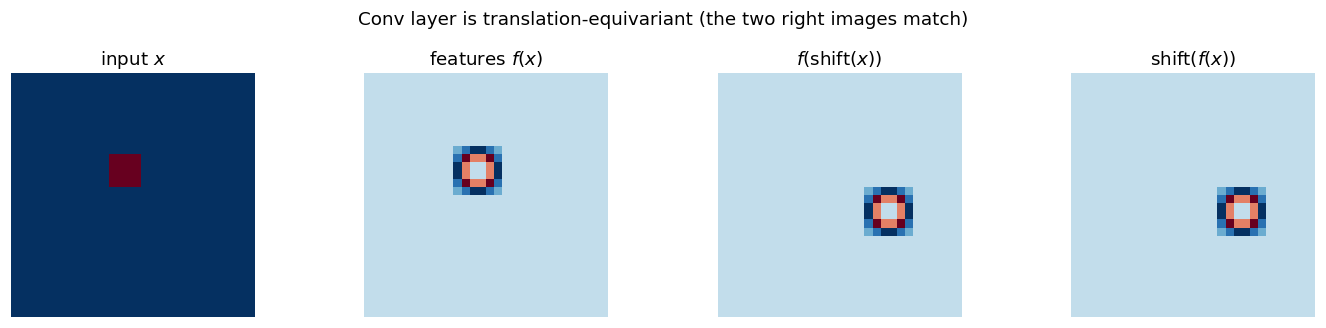

In [2]:
# Toy 'image' with one bright blob
x = np.zeros((30, 30))
x[10:14, 12:16] = 1.0

# An edge-detector filter
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]], dtype=float)

def f(im):
    return convolve2d(im, kernel, mode='same', boundary='fill')

delta = (5, 7)  # pixel shift

left  = f(shift(x, delta, order=0))      # translate then conv
right = shift(f(x), delta, order=0)      # conv then translate

err = np.abs(left - right).max()
print(f'max pixel-wise discrepancy = {err:.2e}  → equivariance holds')

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for ax, im, t in zip(axes,
                     [x, f(x), left, right],
                     ['input $x$', 'features $f(x)$',
                      r'$f(\mathrm{shift}(x))$',
                      r'$\mathrm{shift}(f(x))$']):
    ax.imshow(im, cmap='RdBu_r'); ax.set_title(t); ax.axis('off')
plt.suptitle('Conv layer is translation-equivariant (the two right images match)')
plt.tight_layout(); plt.show()

## 2. Invariance destroys information — the case of 2-D vectors

For $v \in \mathbb{R}^2$, any $\mathrm{SO}(2)$-invariant scalar feature can depend only on $\|v\|$ — all directional information is *destroyed*. Conversely, an equivariant feature (e.g. the identity map) preserves direction.

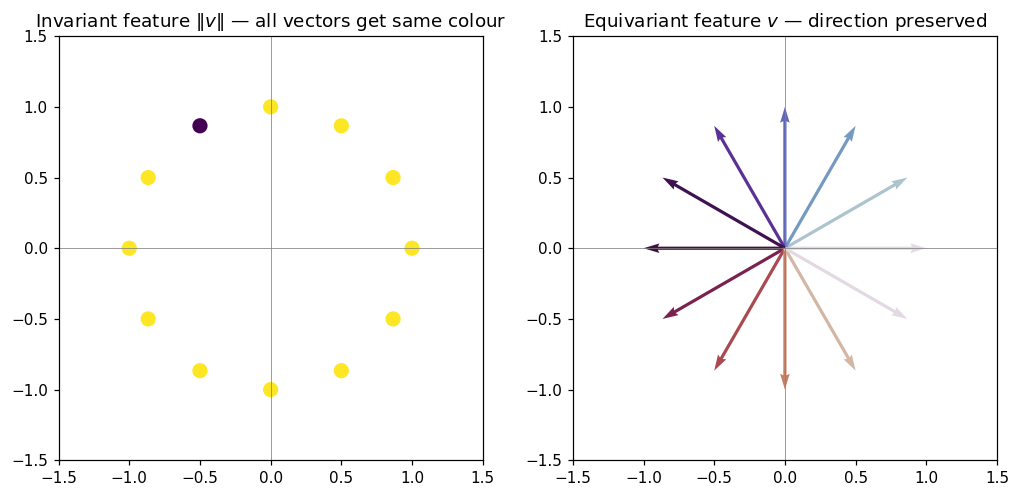

Invariant features are 'colour-blind' to direction;
equivariant features remember it.


In [3]:
# Sample a batch of 2-D vectors of varying directions but same norm
thetas = np.linspace(0, 2*np.pi, 12, endpoint=False)
V = np.stack([np.cos(thetas), np.sin(thetas)], axis=1) * 1.0

# Two candidate features:
inv_feat = np.linalg.norm(V, axis=1)        # invariant: ||v||
equ_feat = V.copy()                          # equivariant: identity

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.5))
axes[0].scatter(V[:,0], V[:,1], c=inv_feat, cmap='viridis', s=80)
axes[0].set_title('Invariant feature $\\|v\\|$ — all vectors get same colour')
axes[0].set_aspect('equal'); axes[0].set_xlim(-1.5,1.5); axes[0].set_ylim(-1.5,1.5)
axes[0].axhline(0, lw=0.5, c='gray'); axes[0].axvline(0, lw=0.5, c='gray')

axes[1].quiver(np.zeros(12), np.zeros(12), V[:,0], V[:,1],
               thetas, cmap='twilight', angles='xy', scale_units='xy', scale=1)
axes[1].set_title('Equivariant feature $v$ — direction preserved')
axes[1].set_aspect('equal'); axes[1].set_xlim(-1.5,1.5); axes[1].set_ylim(-1.5,1.5)
axes[1].axhline(0, lw=0.5, c='gray'); axes[1].axvline(0, lw=0.5, c='gray')
plt.tight_layout(); plt.show()

print("Invariant features are 'colour-blind' to direction;")
print("equivariant features remember it.")

## 3. Permutation-equivariant layer (DeepSets style)

A linear layer $W \in \mathbb{R}^{n\times n}$ is $S_n$-equivariant iff $W$ commutes with every permutation matrix $P_\sigma$.

**Theorem (Zaheer et al., 2017).** Such $W$ must take the form
$$W = \alpha I + \beta \mathbf{1}\mathbf{1}^\top$$
i.e.\ a scalar multiple of the identity plus a scalar multiple of the all-ones matrix.

In [4]:
def perm_matrix(sigma):
    return np.eye(len(sigma))[sigma]

n = 5
alpha, beta = 0.7, -0.2
W_equiv = alpha * np.eye(n) + beta * np.ones((n, n))
W_random = np.random.randn(n, n)

x = np.random.randn(n)
sigma = np.array([2, 4, 0, 3, 1])
P = perm_matrix(sigma)

lhs_equiv  = W_equiv  @ (P @ x);  rhs_equiv  = P @ (W_equiv  @ x)
lhs_random = W_random @ (P @ x);  rhs_random = P @ (W_random @ x)

print('Equivariant W :  ||W(Px) - P(Wx)|| =', np.linalg.norm(lhs_equiv  - rhs_equiv))
print('Random W      :  ||W(Px) - P(Wx)|| =', np.linalg.norm(lhs_random - rhs_random))
print('\nOnly the structured W (αI + β11ᵀ) commutes with the permutation.')

Equivariant W :  ||W(Px) - P(Wx)|| = 1.594436429147036e-16
Random W      :  ||W(Px) - P(Wx)|| = 7.015435265240543

Only the structured W (αI + β11ᵀ) commutes with the permutation.


## 4. ⭐ Striking example — segmentation: equivariant vs not

We build a tiny segmentation toy: each image contains a **brighter blob** in a random location; the target mask is the blob's pixels. We train two heads:

- **FC head**: flatten → linear → sigmoid. *Not* translation-equivariant.
- **Conv head**: a single $3 \times 3$ conv → sigmoid. *Translation-equivariant by construction.*

We train **only on blobs in the top-left quadrant** and evaluate on blobs translated everywhere.

The FC head will overfit to the training region. The conv head will generalise to the whole image without ever having seen a blob outside the training region — a textbook demonstration of equivariance as inductive bias.

In [5]:
H = W_im = 16   # image side

def make_sample(cx, cy, r=2, noise=0.05):
    im = noise * np.random.randn(H, W_im)
    yy, xx = np.meshgrid(np.arange(H), np.arange(W_im), indexing='ij')
    mask = ((yy - cy)**2 + (xx - cx)**2) <= r**2
    im[mask] += 1.0
    return im, mask.astype(float)

# TRAINING SET — blobs only in top-left quadrant (centres in [3,7] x [3,7])
N_train = 400
X_tr, Y_tr = [], []
for _ in range(N_train):
    cx = np.random.randint(3, 8); cy = np.random.randint(3, 8)
    im, m = make_sample(cx, cy)
    X_tr.append(im); Y_tr.append(m)
X_tr = np.array(X_tr); Y_tr = np.array(Y_tr)
print('Training samples shape:', X_tr.shape, '— blobs restricted to top-left quadrant.')

Training samples shape: (400, 16, 16) — blobs restricted to top-left quadrant.


In [6]:
# ----- FC head (not translation-equivariant) ------------------------------
X_flat = X_tr.reshape(N_train, -1)
Y_flat = Y_tr.reshape(N_train, -1)

# Solve linear regression for each output pixel: Y ≈ X W^T + b
X_aug = np.hstack([X_flat, np.ones((N_train, 1))])
W_b = np.linalg.lstsq(X_aug, Y_flat, rcond=None)[0]   # (H*W+1, H*W)

def predict_fc(im):
    v = np.append(im.ravel(), 1.0)
    return (v @ W_b).reshape(H, W_im)

# ----- Conv head (translation-equivariant) --------------------------------
# Learn one 3x3 kernel by least squares on flattened conv-as-linear problem
from numpy.lib.stride_tricks import sliding_window_view

def patches(im, k=3):
    pad = np.pad(im, k//2)
    return sliding_window_view(pad, (k,k)).reshape(-1, k*k)

k = 3
rows = np.vstack([patches(im, k) for im in X_tr])     # (N*H*W, 9)
tgt  = Y_tr.reshape(-1)
rows_aug = np.hstack([rows, np.ones((rows.shape[0],1))])
theta = np.linalg.lstsq(rows_aug, tgt, rcond=None)[0]
kernel_learned = theta[:9].reshape(k, k)
bias_learned   = theta[9]

def predict_conv(im):
    out = convolve2d(im, kernel_learned[::-1, ::-1], mode='same', boundary='fill')
    return out + bias_learned

print('Both heads trained. Learned conv kernel:')
print(np.round(kernel_learned, 2))

Both heads trained. Learned conv kernel:
[[0.04 0.01 0.04]
 [0.01 0.83 0.01]
 [0.04 0.01 0.04]]


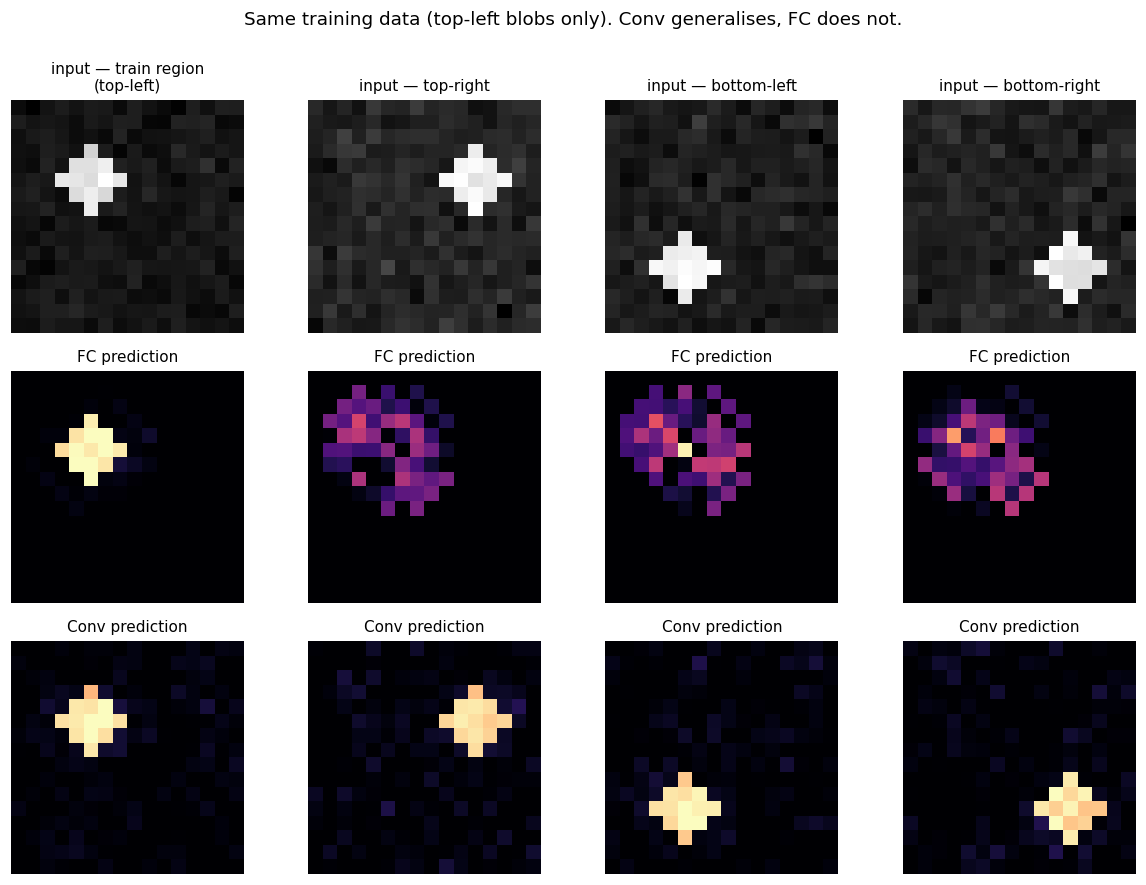

In [7]:
# Test on blobs at four representative positions: in-distribution + 3 OOD shifts
test_centres = [(5,5), (11,5), (5,11), (11,11)]
labels = ['train region\n(top-left)', 'top-right', 'bottom-left', 'bottom-right']

fig, axes = plt.subplots(3, 4, figsize=(11, 8))
for j, ((cx,cy), lab) in enumerate(zip(test_centres, labels)):
    im, gt = make_sample(cx, cy)
    pf = predict_fc(im); pc = predict_conv(im)
    axes[0,j].imshow(im, cmap='gray');   axes[0,j].set_title(f'input — {lab}', fontsize=10)
    axes[1,j].imshow(pf, cmap='magma', vmin=0, vmax=1); axes[1,j].set_title('FC prediction', fontsize=10)
    axes[2,j].imshow(pc, cmap='magma', vmin=0, vmax=1); axes[2,j].set_title('Conv prediction', fontsize=10)
    for ax in axes[:,j]: ax.axis('off')
axes[1,0].set_ylabel('FC head\n(not equivariant)', fontsize=10)
axes[2,0].set_ylabel('Conv head\n(equivariant)',   fontsize=10)
plt.suptitle('Same training data (top-left blobs only). Conv generalises, FC does not.',
             fontsize=12, y=1.00)
plt.tight_layout(); plt.show()

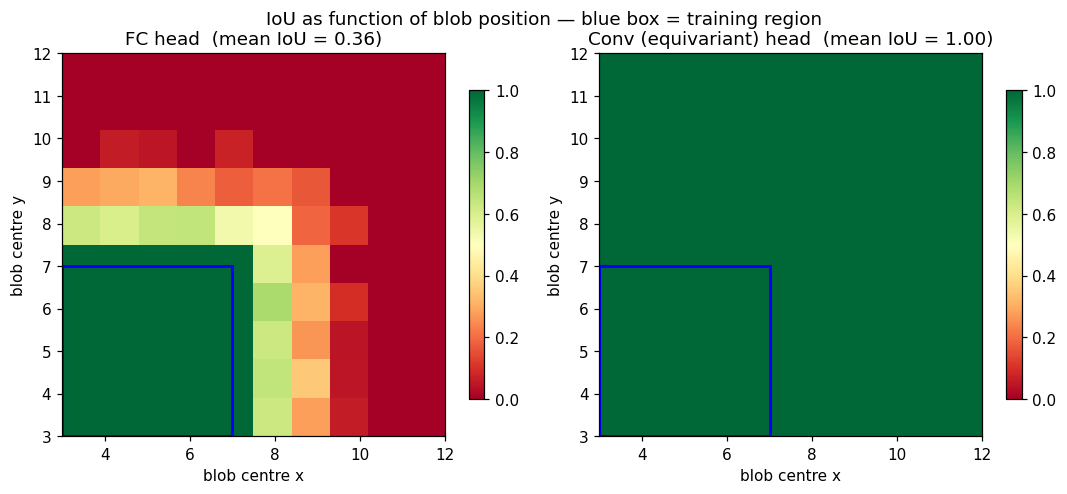

In [8]:
# Quantitative: IoU across the whole image plane
def iou(pred, gt, thresh=0.5):
    p = pred > thresh; g = gt > 0.5
    return (p & g).sum() / max((p | g).sum(), 1)

iou_fc, iou_cv = [], []
centres = [(cx, cy) for cx in range(3, 13) for cy in range(3, 13)]
for cx, cy in centres:
    im, gt = make_sample(cx, cy)
    iou_fc.append(iou(predict_fc(im), gt))
    iou_cv.append(iou(predict_conv(im), gt))

iou_fc = np.array(iou_fc).reshape(10, 10)
iou_cv = np.array(iou_cv).reshape(10, 10)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
for ax, M, t in zip(axes, [iou_fc, iou_cv], ['FC head', 'Conv (equivariant) head']):
    im = ax.imshow(M, cmap='RdYlGn', vmin=0, vmax=1,
                   extent=[3,12,3,12], origin='lower')
    ax.add_patch(plt.Rectangle((3,3), 4, 4, fill=False, ec='blue', lw=2))
    ax.set_title(f'{t}  (mean IoU = {M.mean():.2f})')
    ax.set_xlabel('blob centre x'); ax.set_ylabel('blob centre y')
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('IoU as function of blob position — blue box = training region')
plt.tight_layout(); plt.show()

**Reading the plot.** The FC head only knows how to detect blobs in the blue (training) box — its IoU collapses outside. The convolutional head is *translation-equivariant by construction*: the kernel knows nothing about absolute position, so it works uniformly across the entire image.

This is the cleanest empirical demonstration of:

> *Hard-coded equivariance beats learning to generalise across translations.*

## Exercises

1. The FC head has $H^2 \cdot W^2 \approx 65{,}000$ parameters; the conv head has $9 + 1 = 10$. Verify these numbers in code and discuss the implication.
2. Add a global pooling step to the conv head. Is the new map invariant or equivariant under translation? Verify on a translated image.
3. Replace the 2-D blob detector with a *3-D* one and discuss what symmetry group is now appropriate.